In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
FEMALE_PATH = "/Users/suo/DSI/visualization/02_activities/assignments/5d2df591-33d4-4b36-bb1d-e3d8d74633ae.csv"

In [4]:
MALE_PATH = "/Users/suo/DSI/visualization/02_activities/assignments/9571139d-e505-4a35-82fa-192af66c5714.csv"

In [5]:
def load_and_rank(path: str, sex: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.rename(columns={
        "Year/Année": "year",
        "Name/Nom": "name",
        "Frequency/Fréquence": "frequency"
    })
    df["sex"] = sex
    df["name"] = df["name"].astype(str).str.title()
    df["rank_in_year"] = (
        df.sort_values(["year", "frequency"], ascending=[True, False])
          .groupby("year")["frequency"]
          .rank(method="dense", ascending=False)
          .astype(int)
    )
    return df[["year", "name", "frequency", "sex", "rank_in_year"]]

df_f = load_and_rank(FEMALE_PATH, "female")
df_m = load_and_rank(MALE_PATH, "male")
df = pd.concat([df_f, df_m], ignore_index=True)

In [6]:
df_recent = df[df["year"].between(2000, 2023)].copy()


In [7]:
track_female = ["Olivia", "Emma", "Sophia", "Isabella", "Ava"]
track_male = ["Liam", "Noah", "Oliver", "Ethan", "Jacob"]


In [8]:
df_track = df_recent[
    ((df_recent["sex"] == "female") & (df_recent["name"].isin(track_female))) |
    ((df_recent["sex"] == "male") & (df_recent["name"].isin(track_male)))
].copy()

plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

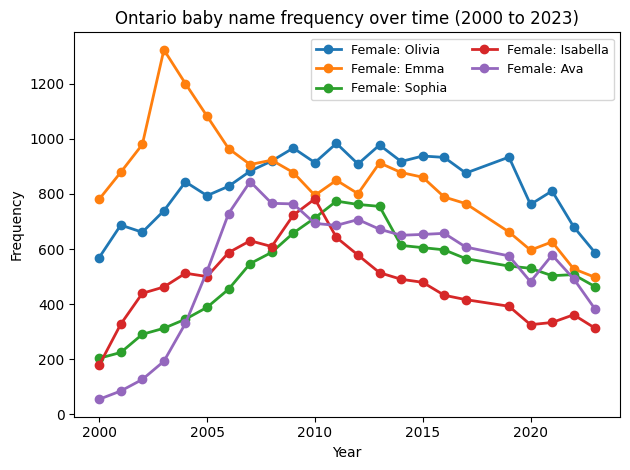

In [11]:
for n in track_female:
    sub = df_track[(df_track["sex"] == "female") & (df_track["name"] == n)]
    plt.plot(sub["year"], sub["frequency"], marker="o", linewidth=2, label=f"Female: {n}")
plt.title("Ontario baby name frequency over time (2000 to 2023)")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig("viz_1_python_trends.png", dpi=300)
plt.show()

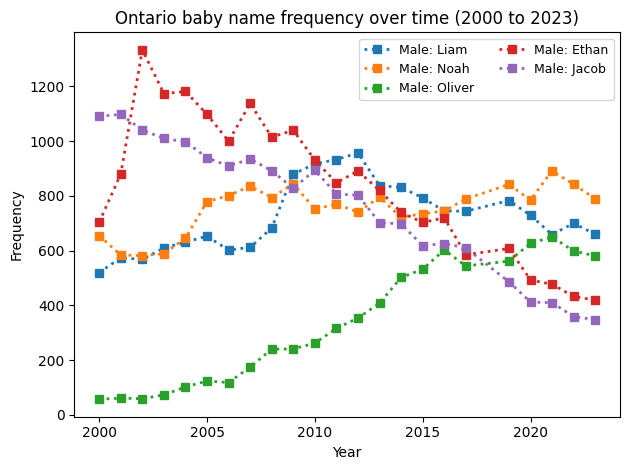

In [10]:
for n in track_male:
    sub = df_track[(df_track["sex"] == "male") & (df_track["name"] == n)]
    plt.plot(sub["year"], sub["frequency"], marker="s", linewidth=2, linestyle=":", label=f"Male: {n}")

plt.title("Ontario baby name frequency over time (2000 to 2023)")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig("viz_1_python_trends.png", dpi=300)
plt.show()